In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('systematic mapping MCDM Scopus - revisión.csv',sep=',')

In [4]:
df.dropna(subset=['MCDM method'],inplace=True)

In [5]:
hybrid_models = len(df[df['MCDM method'].str.contains(',', na=False)])
individual_models = len(df)-len(df[df['MCDM method'].str.contains(',', na=False)])


In [6]:
mask = df['Solar/Eolico'] == 'Solar'
df = df[~mask]

### Publicaciones por año

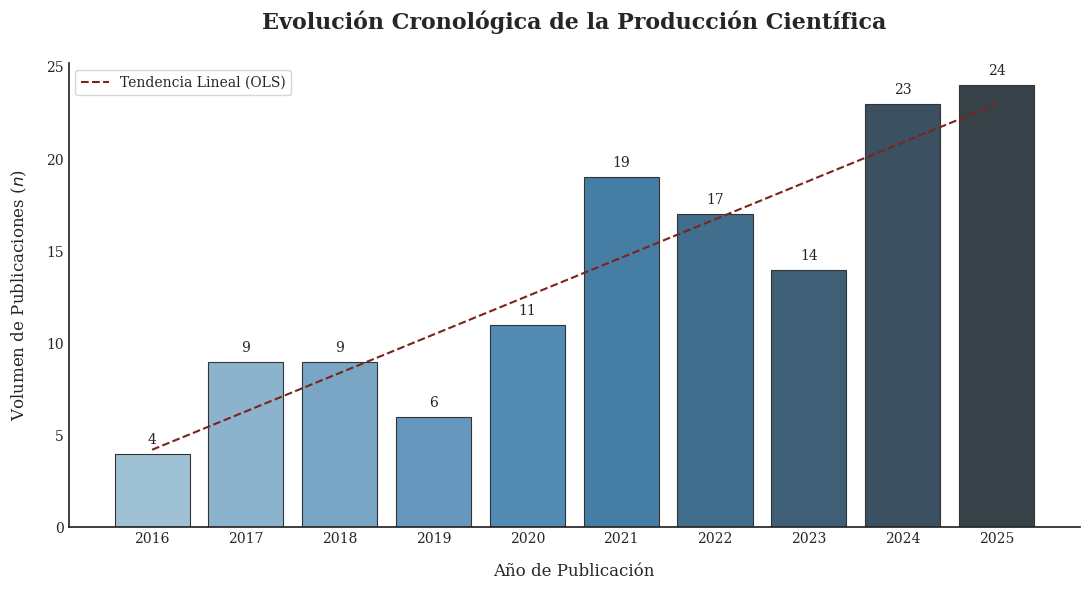

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

# --- 1. Preparación de datos ---
# (Asumiendo que df['Year'] existe)
counts = df['Year'].value_counts().sort_index()[:-1]
x_values = np.arange(len(counts)).reshape(-1, 1) # Usamos índices para la regresión
y_values = counts.values

# --- 2. Cálculo de la Regresión Lineal ---
model = LinearRegression()
model.fit(x_values, y_values)
y_pred = model.predict(x_values)

# --- 3. Configuración de Estilo Académico ---
plt.style.use('seaborn-v0_8-white')
plt.figure(figsize=(11, 6), dpi=100)

# Paleta formal: Degradado de azules oscuros (SteelBlue)
colors = sns.color_palette("Blues_d", len(counts))

# Gráfico de barras
ax = sns.barplot(
    x=counts.index.astype(str), 
    y=counts.values, 
    palette=colors, 
    hue=counts.index.astype(str), 
    legend=False,
    edgecolor="0.2", # Borde fino para definición
    linewidth=0.8
)

# Línea de Tendencia (más sobria, color gris oscuro o borgoña profundo)
plt.plot(range(len(counts)), y_pred, color='#7B241C', linestyle='--', linewidth=1.5, label='Tendencia Lineal (OLS)')

# --- 4. Personalización Formal ---
plt.title('Evolución Cronológica de la Producción Científica', 
          fontsize=16, fontweight='bold', pad=25, fontfamily='serif', loc='center')

plt.xlabel('Año de Publicación', fontsize=12, fontfamily='serif', labelpad=12)
plt.ylabel('Volumen de Publicaciones ($n$)', fontsize=12, fontfamily='serif', labelpad=12)

# Etiquetas sobre las barras (solo si los valores son legibles)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, fontfamily='serif', 
                xytext=(0, 5), textcoords='offset points')

# --- 5. Ajustes de Ejes y Limpieza ---
plt.xticks(rotation=0, fontsize=10, fontfamily='serif') # Rotación 0 para más orden
plt.yticks(fontsize=10, fontfamily='serif')
sns.despine() # Quita los marcos superior y derecho

# Leyenda discreta
plt.legend(frameon=True, fontsize=10, loc='upper left', prop={'family': 'serif'})

plt.tight_layout()
plt.show()

### Por país

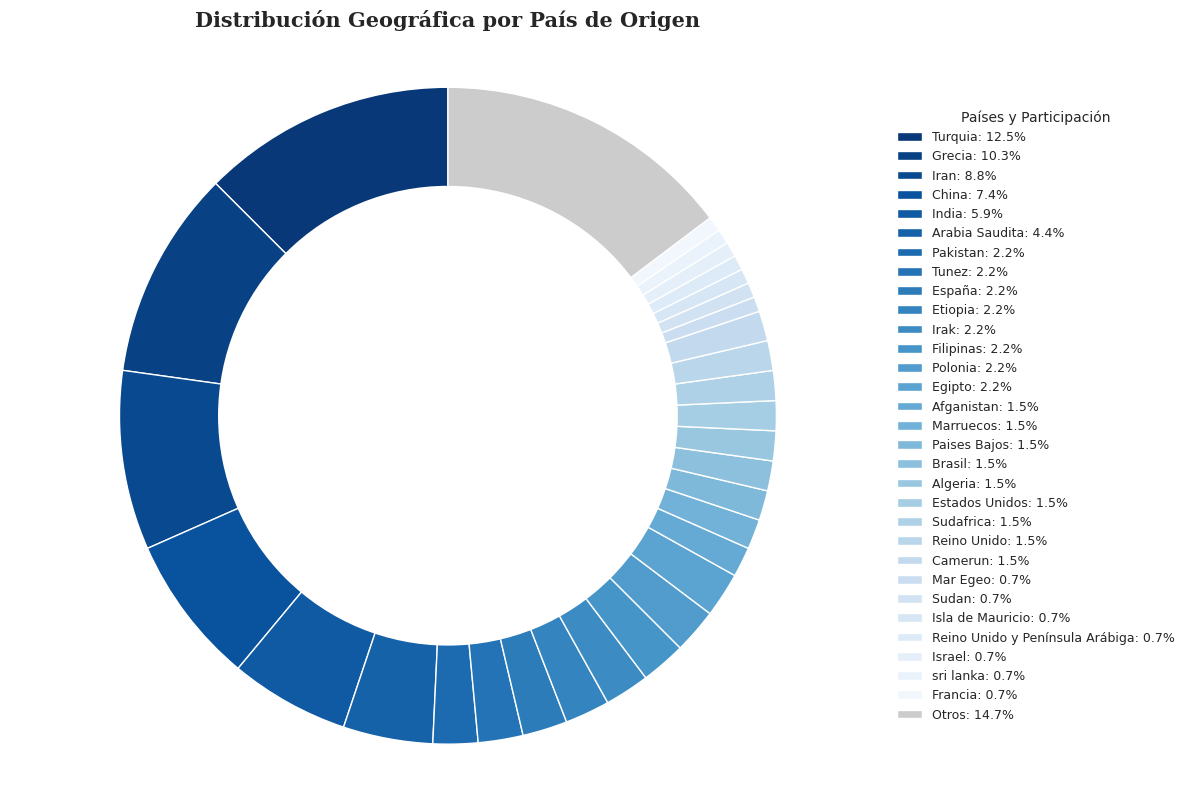

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Preparación de datos ---
counts = df['país'].value_counts()
n_top = 30
top_n = counts.head(n_top)
others_count = counts.iloc[n_top:].sum()
data_plot = pd.concat([top_n, pd.Series({'Otros': others_count})])

# --- 2. Paleta Formal ---
blue_palette = sns.color_palette("Blues_r", n_top)
colors = [c for c in blue_palette]
colors.append((0.8, 0.8, 0.8)) # Gris para "Otros"

# --- 3. Configuración ---
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)

# --- 4. Gráfico de Tarta (Limpio, sin texto interno) ---
wedges, texts = ax.pie(
    data_plot.values, 
    labels=None,          # Eliminamos etiquetas directas
    autopct=None,        # Eliminamos porcentajes internos para evitar el caos visual
    startangle=90, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'antialiased': True}
)

# Círculo central
centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax.add_artist(centre_circle)

# --- 5. Leyenda Inteligente (Nombre + Porcentaje) ---
# Calculamos los porcentajes manualmente para la leyenda
total = data_plot.sum()
labels_with_pct = [f'{l}: {(v/total)*100:1.1f}%' for l, v in zip(data_plot.index, data_plot.values)]

ax.legend(
    wedges, 
    labels_with_pct,
    title="Países y Participación",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9,
    frameon=False
)

# --- 6. Título y Estética ---
plt.title('Distribución Geográfica por País de Origen', 
          fontsize=15, fontweight='bold', pad=20, fontfamily='serif')

plt.axis('equal') 
plt.tight_layout()
plt.show()

Modelos individuales

### Modelos híbridos VS individuales

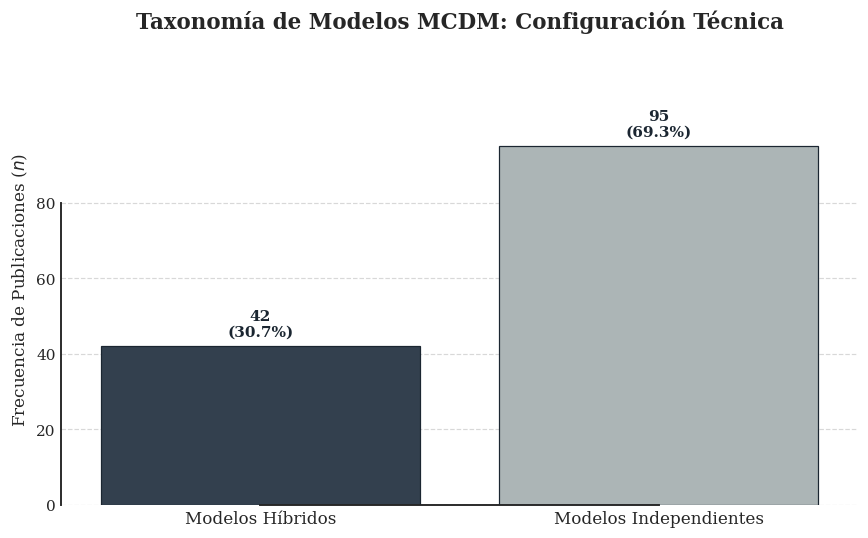

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparación de Datos
hybrid_models = len(df[df['MCDM method'].str.contains(',', na=False)])
single_models = len(df) - hybrid_models

labels = ['Modelos Híbridos', 'Modelos Independientes']
values = [hybrid_models, single_models]
total = sum(values)

# 2. Configuración de Estilo Editorial
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(8, 5), dpi=110)

# 3. Creación del Gráfico (Paleta de Contraste Formal)
# Usamos un azul profundo para híbridos y un gris neutro para independientes
colors = ['#2E4053', '#AAB7B8'] 

sns.barplot(
    x=labels, 
    y=values, 
    palette=colors, 
    hue=labels, 
    legend=False,
    edgecolor='#1B2631', 
    linewidth=0.8,
    ax=ax
)

# 4. Anotaciones Profesionales (Valor absoluto + Porcentaje)
for i, v in enumerate(values):
    percentage = (v / total) * 100
    ax.text(i, v + (max(values) * 0.02), f'{int(v)}\n({percentage:.1f}%)', 
            ha='center', va='bottom', 
            fontsize=10, fontfamily='serif', 
            fontweight='bold', color='#1B2631')

# 5. Títulos y Etiquetas (Journal Style)
plt.title('Taxonomía de Modelos MCDM: Configuración Técnica', 
          fontsize=14, fontweight='bold', pad=30, fontfamily='serif', loc='center')

plt.ylabel('Frecuencia de Publicaciones ($n$)', fontsize=11, fontfamily='serif')
plt.xlabel('', )

# 6. Refinamiento de Ejes
plt.xticks(fontsize=11, fontfamily='serif')
plt.yticks(fontsize=10, fontfamily='serif')

# Limpieza de "Tinta" y rejilla sutil
sns.despine(trim=True) 
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)

# Añadir un margen superior para las etiquetas
plt.ylim(0, max(values) * 1.2)

plt.tight_layout()
plt.show()

### Distribución modelos Individuales

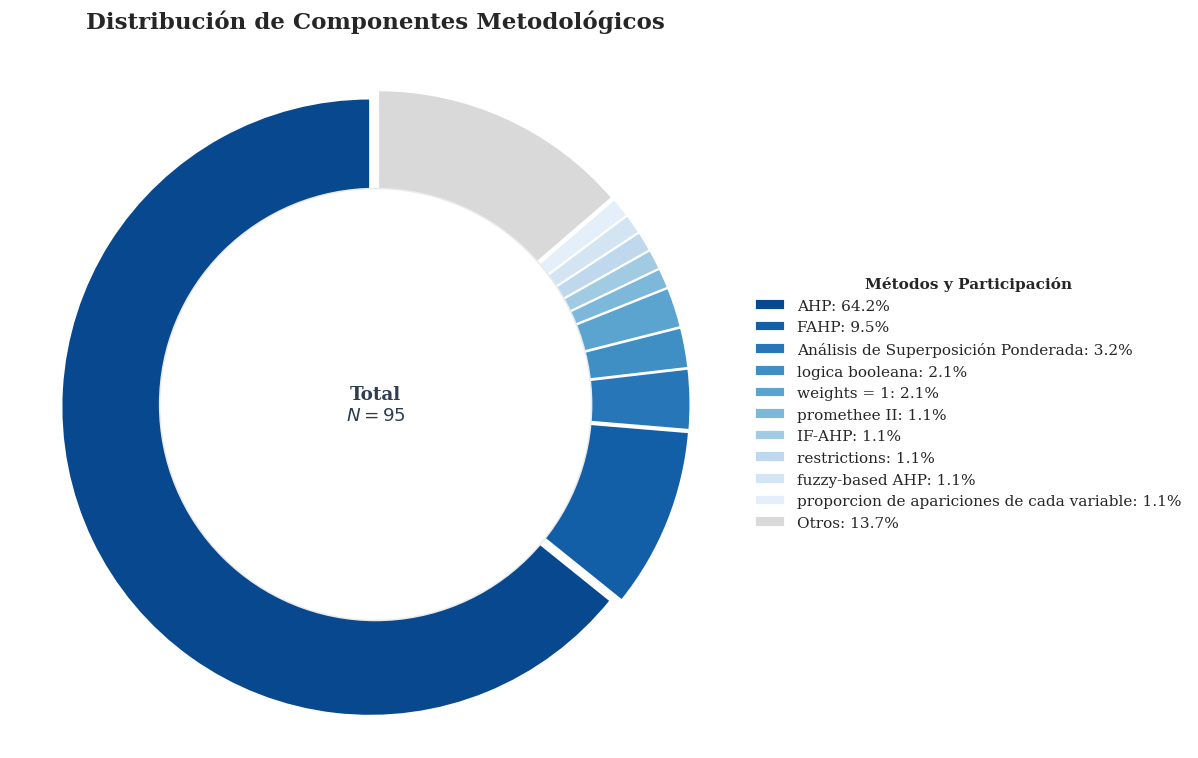

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Preparación de datos (Igual a tu lógica) ---
hybrid_df = df[~df['MCDM method'].str.contains(',', na=False)]
split_counts = hybrid_df['MCDM method'].str.strip().value_counts()

n_top = 10 
top_elements = split_counts.head(n_top).copy()
others_sum = split_counts.iloc[n_top:].sum()
if others_sum > 0:
    top_elements['Otros'] = others_sum

# --- 2. Estilo Editorial y Colores ---
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(11, 7), dpi=110)

# Paleta de Azules Profesionales (Secuencial)
colors = sns.color_palette("Blues_r", len(top_elements) - 1)
colors.append((0.85, 0.85, 0.85)) # Gris para "Otros"

# --- 3. Crear el gráfico de Dona (SIN texto interno) ---
wedges, _ = ax.pie(
    top_elements.values, 
    labels=None,          # Quitamos etiquetas externas
    autopct=None,        # Quitamos porcentajes internos para evitar el desorden
    startangle=90, 
    colors=colors,
    pctdistance=0.85,
    explode=[0.02] * len(top_elements),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2, 'antialiased': True}
)

# Círculo blanco central (Efecto Dona)
centre_circle = plt.Circle((0,0), 0.70, fc='white', edgecolor='#EAEAEA')
ax.add_artist(centre_circle)

# --- 4. Título e Información en el Centro ---
# Un toque muy formal es poner el total de la muestra en el centro de la dona
total_n = top_elements.sum()
ax.text(0, 0, f'Total\n$N={total_n}$', ha='center', va='center', 
        fontsize=12, fontfamily='serif', fontweight='bold', color='#2C3E50')

# --- 5. Leyenda Externa: El secreto de la legibilidad ---
# Creamos etiquetas que incluyan el nombre y el porcentaje
percentages = 100 * top_elements.values / total_n
legend_labels = [f'{l}: {p:.1f}%' for l, p in zip(top_elements.index, percentages)]

ax.legend(
    wedges, 
    legend_labels,
    title="Métodos y Participación",
    title_fontproperties={'weight':'bold', 'family':'serif'},
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), # Mueve la leyenda fuera del gráfico
    fontsize=10,
    prop={'family': 'serif'},
    frameon=False
)

# --- 6. Toque Final ---
plt.title('Distribución de Componentes Metodológicos', 
          fontsize=15, fontweight='bold', pad=20, fontfamily='serif')

plt.axis('equal') 
plt.tight_layout()
plt.show()

### Onshore/Offshore

/tmp/ipykernel_7481/4245535115.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontfamily='serif')


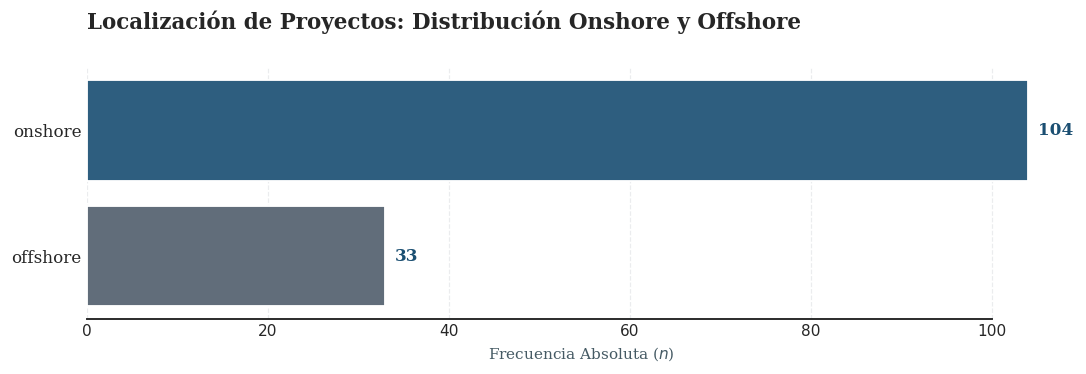

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparación de Datos
counts = df['onshore/offshore'].value_counts()

# 2. Configuración de Estilo Editorial
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(10, 3.5), dpi=110)

# 3. Creación de Barras (Paleta Institucional)
# Azul profundo para la categoría principal, gris pizarra para la comparativa
colors = ['#21618C', '#5D6D7E'] 

sns.barplot(
    x=counts.values, 
    y=counts.index.astype(str), 
    palette=colors,
    hue=counts.index.astype(str),
    legend=False,
    edgecolor='#FFFFFF',
    linewidth=1.2,
    ax=ax
)

# 4. Anotaciones de Datos (Estilo Serif)
max_val = counts.values.max()
for i, v in enumerate(counts.values):
    ax.text(v + (max_val * 0.01), i, f'{int(v)}', 
            va='center', 
            fontsize=11, 
            fontfamily='serif',
            fontweight='bold', 
            color='#1B4F72')

# 5. Refinamiento de Títulos y Ejes
# Usamos un título descriptivo y formal
plt.title('Localización de Proyectos: Distribución Onshore y Offshore', 
          fontsize=14, fontweight='bold', pad=25, fontfamily='serif', loc='left')

plt.xlabel('Frecuencia Absoluta ($n$)', fontsize=10, fontfamily='serif', color='#455A64')
plt.ylabel('') 

# Configuración de etiquetas del eje Y
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontfamily='serif')

# 6. Limpieza Visual (Minimalismo Científico)
sns.despine(left=True, bottom=False, trim=True) 
ax.xaxis.grid(True, linestyle='--', alpha=0.3, color='#BDC3C7')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Distribución modelos híbridos

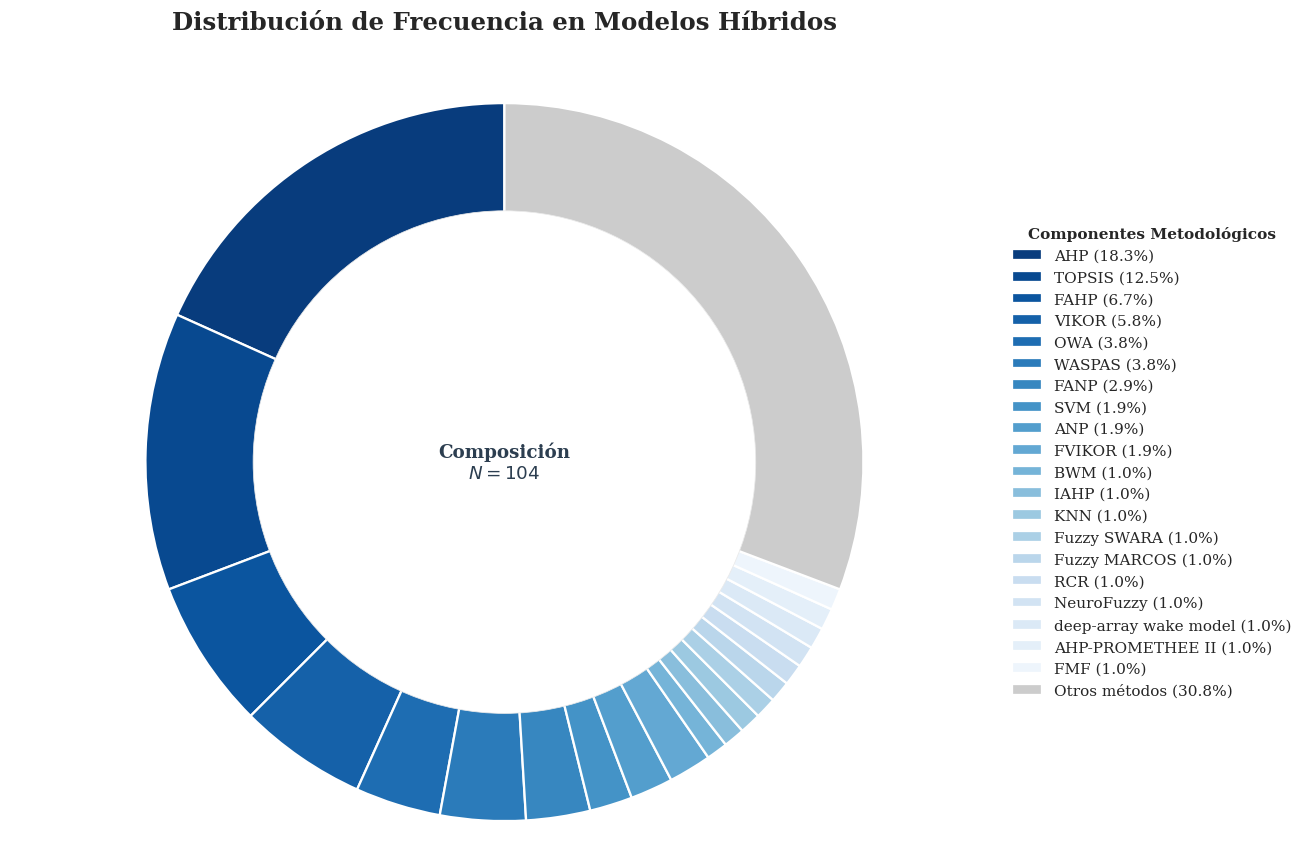

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Preparación de datos ---
hybrid_df = df[df['MCDM method'].str.contains(',', na=False)]
split_counts = hybrid_df['MCDM method'].str.split(',').explode().str.strip().value_counts()

# Con 30 categorías, la torta se satura. Bajamos a las 12 más importantes + Otros 
# para que el gráfico sea legible y profesional.
n_top = 20
top_elements = split_counts.head(n_top).copy()
others_sum = split_counts.iloc[n_top:].sum()

if others_sum > 0:
    top_elements['Otros métodos'] = others_sum

# --- 2. Configuración de Estilo Académico ---
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(12, 8), dpi=110)

# Paleta: Degradado de azules para el top, gris para "Otros"
colors = sns.color_palette("Blues_r", len(top_elements)-1)
colors.append((0.8, 0.8, 0.8)) # Gris neutro para "Otros"

# --- 3. Creación del Gráfico de Dona ---
# No ponemos etiquetas (labels=None) ni porcentajes internos para evitar solapamiento
wedges, _ = ax.pie(
    top_elements.values, 
    labels=None, 
    autopct=None, 
    startangle=90, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'antialiased': True}
)

# Círculo blanco central (Efecto Dona)
centre_circle = plt.Circle((0,0), 0.70, fc='white', edgecolor='#EAEAEA', linewidth=0.5)
ax.add_artist(centre_circle)

# --- 4. Información Central ---
total_n = top_elements.sum()
ax.text(0, 0, f'Composición\n$N={total_n}$', ha='center', va='center', 
        fontsize=12, fontfamily='serif', fontweight='bold', color='#2C3E50')

# --- 5. Leyenda Externa Detallada ---
# Generamos etiquetas con nombre y porcentaje para la leyenda
legend_labels = []
for i, (name, val) in enumerate(top_elements.items()):
    pct = (val / total_n) * 100
    legend_labels.append(f'{name} ({pct:.1f}%)')

ax.legend(
    wedges, 
    legend_labels,
    title="Componentes Metodológicos",
    title_fontproperties={'weight':'bold', 'family':'serif'},
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), # Fuera del círculo
    fontsize=9,
    prop={'family': 'serif'},
    frameon=False
)

# --- 6. Título y Ajustes ---
plt.title('Distribución de Frecuencia en Modelos Híbridos', 
          fontsize=16, fontweight='bold', pad=25, fontfamily='serif')

plt.axis('equal') 
plt.tight_layout()
plt.show()

### Matriz Co-ocurrencia

<bound method Axes.set of <Axes: title={'center': 'Matriz de Co-ocurrencia de Métodos MCDM (Top 30)'}, xlabel='Métodos Complementarios'>>

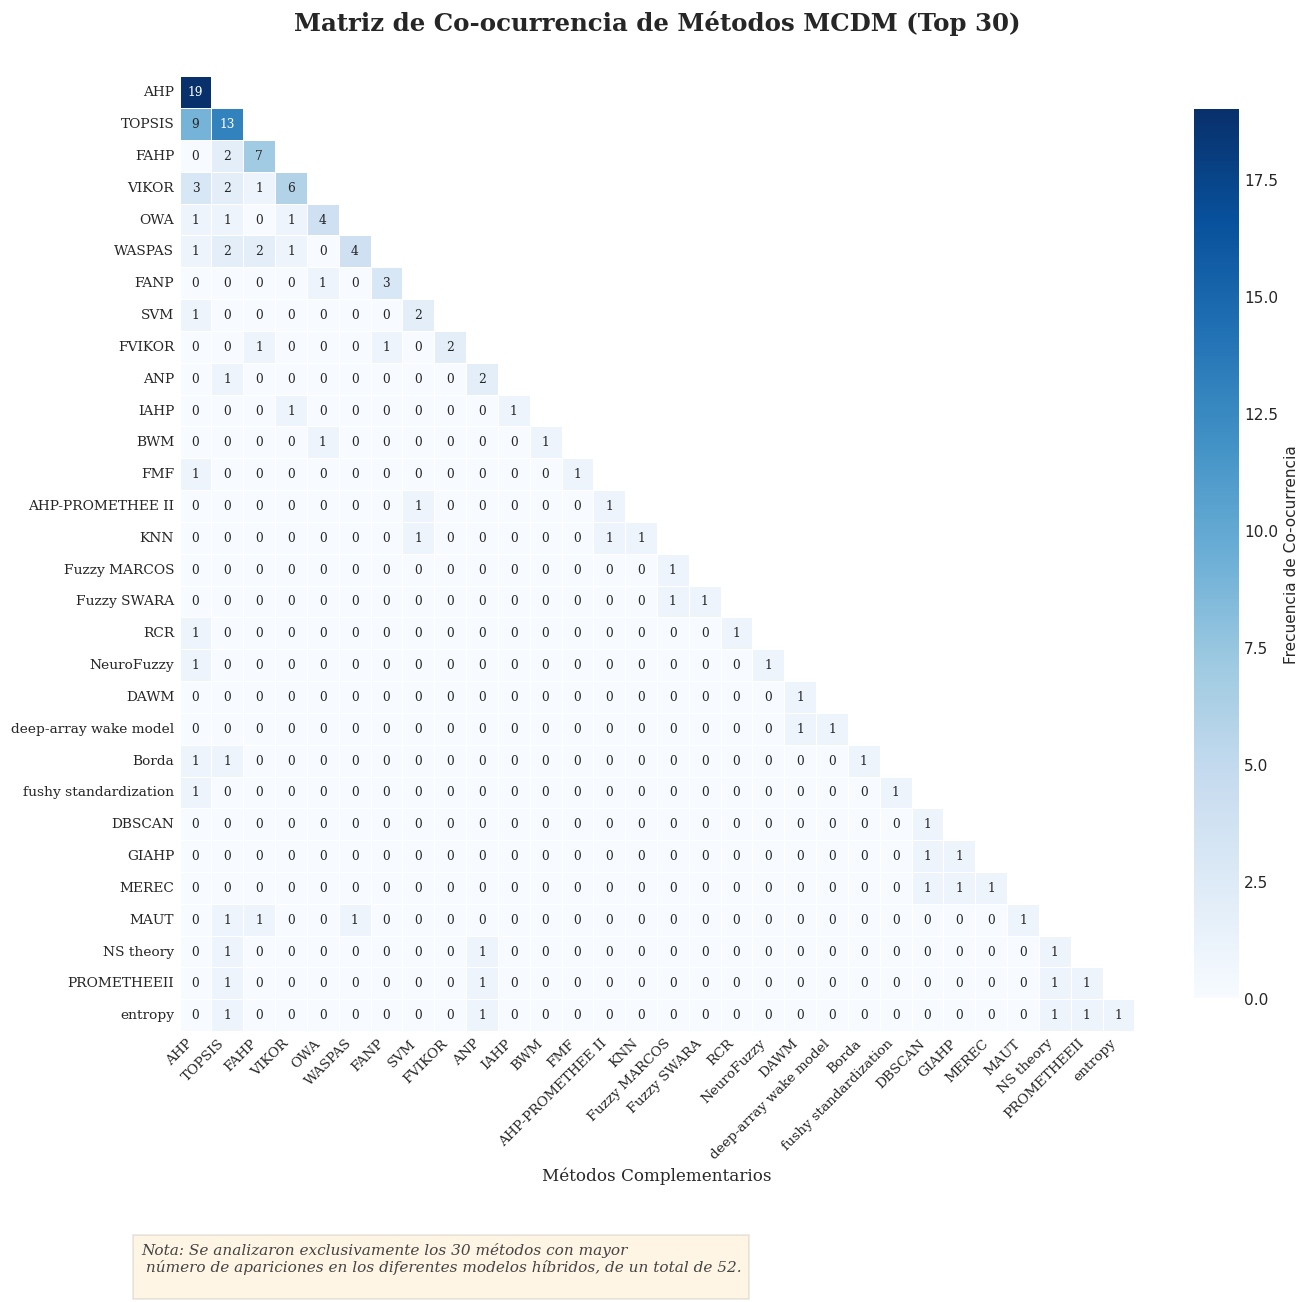

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# --- 1. Preparación de la Matriz ---
hybrid_df = df[df['MCDM method'].str.contains(',', na=False)]
total_hybrid_papers = len(hybrid_df)

pair_counts = Counter()
method_freq = Counter()

for methods_str in hybrid_df['MCDM method']:
    methods = sorted(list(set([m.strip() for m in methods_str.split(',')])))
    method_freq.update(methods)
    for pair in combinations(methods, 2):
        pair_counts[pair] += 1

# Selección de Top N
n_top = 30
top_methods = [m for m, count in method_freq.most_common(n_top)]
ignored_methods_count = len(method_freq) - len(top_methods)

# --- Cálculo de representatividad ---
# Contamos cuántos papers tienen al menos uno de los métodos top
papers_covered = hybrid_df['MCDM method'].apply(
    lambda x: any(m.strip() in top_methods for m in x.split(','))
).sum()
ignored_papers = total_hybrid_papers - papers_covered

# --- 2. Creación de la Matriz ---
cooc_matrix = pd.DataFrame(0, index=top_methods, columns=top_methods)
for (m1, m2), count in pair_counts.items():
    if m1 in top_methods and m2 in top_methods:
        cooc_matrix.loc[m1, m2] = count
        cooc_matrix.loc[m2, m1] = count

for m in top_methods:
    cooc_matrix.loc[m, m] = method_freq[m]

# --- 3. Visualización Académica ---
plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(14, 15), dpi=110)

mask = np.triu(np.ones_like(cooc_matrix, dtype=bool), k=1)

sns.heatmap(
    cooc_matrix, 
    annot=True, fmt="d", cmap="Blues", mask=mask, square=True,
    linewidths=.5, cbar_kws={"shrink": .7, "label": "Frecuencia de Co-ocurrencia"},
    annot_kws={"size": 8, "fontfamily": "serif"}
)

# --- 4. Títulos y Notas (Aclaración de Datos) ---
plt.title('Matriz de Co-ocurrencia de Métodos MCDM (Top 30)', 
          fontsize=16, fontweight='bold', pad=30, fontfamily='serif')

# Texto aclaratorio en la parte inferior (Nota al pie)
info_text = (
    f"Nota: Se analizaron exclusivamente los 30 métodos con mayor \n número de apariciones en los diferentes modelos híbridos, de un total de 52.\n"
)

# Añadir la nota al pie del gráfico
plt.figtext(0.1, 0.05, info_text, ha="left", fontsize=10, 
            fontfamily='serif', style='italic', color='#444444', 
            bbox={"facecolor":"orange", "alpha":0.1, "pad":5})

plt.xticks(rotation=45, ha='right', fontsize=9, fontfamily='serif')
plt.yticks(fontsize=9, fontfamily='serif')
ax.set_xlabel('Métodos Complementarios', fontsize=11, fontfamily='serif')
ax.set